# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/atulpatel-net/FlyRank_ML_In/blob/main/work/notebooks/capstone.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

### Research question

Can historical search-performance signals be used to prioritize content that may warrant human review for declining organic search visibility?

### Decision supported

The analysis supports a practical decision: **which content should be reviewed first**, based on measured historical performance signals.

The output is intended as decision-support for content and SEO teams. It does not determine whether content should be changed, nor does it establish that a predicted decline will occur.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

### Dataset

This analysis uses the FlyRank ML Internship dataset from the `FlyRank/internship-warehouse` release, using the `fact_content_daily_performance` data.

The available daily data covers **27 January 2025 through 30 June 2026**, with approximately **78.8 million rows** across the available monthly files.

### Modeling window

For each client-content pair, the analysis uses a 60-day observation window relative to the latest available reporting date:

- **Previous 30 days:** historical baseline used to construct impressions, clicks, and average-position features.
- **Most recent 30 days:** used to measure subsequent impressions and define the observed decline label.

Only rows with `imp_prev30 > 0` were retained so that the decline comparison had a positive historical impression baseline.

### Features

The model uses three historical performance features:

- Previous-30-day impressions
- Previous-30-day clicks
- Previous-30-day average position

Client and content identifiers are anonymized and are used for grouping and traceability within the analysis.

### Exclusions and public-safety

The public repository does not contain the underlying bulk dataset. The analysis excludes observations without positive previous-30-day impressions and does not publish client names, URLs, private search queries, or other identifying information.

The dataset is used for research and decision-support analysis; the outputs should not be interpreted as a production monitoring system.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Methodology

#### Features

The model uses three historical search-performance features calculated from the previous 30-day window:

- `imp_prev30` — total Google Search Console impressions.
- `clk_prev30` — total Google Search Console clicks.
- `pos_prev30` — average Google Search Console position.

These features are intended to represent recent historical visibility and engagement signals.

#### Label definition

The target `is_declining` is defined as:

`imp_last30 < 0.8 × imp_prev30`

A value of `1` indicates that impressions in the most recent 30-day window are below 80% of the previous 30-day baseline. This is an observed performance label, not a causal definition of content quality or future decline.

#### Model

A Random Forest classifier was used to learn the relationship between the historical features and the defined decline label.

The Week-4 rule-based approach was retained as the baseline. Both approaches were evaluated on the same test observations for comparison.

#### Validation design

A row-level random split was first evaluated as a reference.

The primary evaluation uses a **client-grouped split**, with 75% of clients used for training and 25% held out for testing. This prevents the same client from appearing in both training and test sets.

The grouped evaluation is treated as the more honest estimate because the model is evaluated on clients it did not see during training.

#### Leakage audit

The feature construction was reviewed for target leakage. The model features use only the previous 30-day window, while the decline label is determined from the subsequent 30-day window.

Client grouping was also checked after splitting, with **zero client overlap** between the grouped training and test sets.

The analysis therefore avoids using the target-period impression outcome as a model feature and avoids client-level overlap in the primary validation.

#### Assumptions

The analysis assumes that historical impressions, clicks, and average position contain useful directional information for prioritizing content for review.

It does not assume that these variables explain why performance changes or that model predictions establish future causal outcomes.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [1]:
import duckdb
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [11]:
data = con.sql("""
WITH bounds AS (
    SELECT DATE '2026-06-30' AS end_d
),

features AS (
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(
            CASE
                WHEN report_date BETWEEN end_d - INTERVAL 59 DAY
                                     AND end_d - INTERVAL 30 DAY
                THEN gsc_impressions
                ELSE 0
            END
        ) AS imp_prev30,

        SUM(
            CASE
                WHEN report_date BETWEEN end_d - INTERVAL 29 DAY
                                     AND end_d
                THEN gsc_impressions
                ELSE 0
            END
        ) AS imp_last30,

        SUM(
            CASE
                WHEN report_date BETWEEN end_d - INTERVAL 59 DAY
                                     AND end_d - INTERVAL 30 DAY
                THEN gsc_clicks
                ELSE 0
            END
        ) AS clk_prev30,

        AVG(
            CASE
                WHEN report_date BETWEEN end_d - INTERVAL 59 DAY
                                     AND end_d - INTERVAL 30 DAY
                THEN gsc_avg_position
            END
        ) AS pos_prev30

    FROM read_parquet([
        'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-05/data_0.parquet',
        'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-06/data_0.parquet'
    ]), bounds

    GROUP BY
        client_hash_id,
        content_hash_id
)

SELECT *
FROM features
WHERE imp_prev30 > 0
""").df()

print("Dataset shape:", data.shape)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Dataset shape: (237429, 6)


In [12]:
data["is_declining"] = (
    data["imp_last30"] < 0.8 * data["imp_prev30"]
).astype(int)

feature_cols = [
    "imp_prev30",
    "clk_prev30",
    "pos_prev30"
]

X = data[feature_cols]
y = data["is_declining"]
groups = data["client_hash_id"]

print("Features:", feature_cols)
print("Rows:", len(data))
print("Declining:", int(y.sum()))
print("Non-declining:", int((y == 0).sum()))
print("Unique clients:", groups.nunique())


Features: ['imp_prev30', 'clk_prev30', 'pos_prev30']
Rows: 237429
Declining: 169864
Non-declining: 67565
Unique clients: 56


In [13]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Training rows:", len(train_idx))
print("Test rows:", len(test_idx))
print(
    "Client overlap:",
    len(
        set(groups.iloc[train_idx])
        & set(groups.iloc[test_idx])
    )
)

Training rows: 194871
Test rows: 42558
Client overlap: 0


In [14]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest trained.")

Random Forest trained.


In [15]:
# Week-4 rule-based baseline on the same client-grouped test set

baseline_test = data.iloc[test_idx].copy()

baseline_pred = (
    (baseline_test["imp_prev30"] >= 100)
    &
    (baseline_test["clk_prev30"] == 0)
    &
    (baseline_test["pos_prev30"] <= 10)
).astype(int).values


# Comparison

results = pd.DataFrame({
    "Model": [
        "Week-4 Rule Baseline",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, baseline_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, baseline_pred, zero_division=0),
        precision_score(y_test, rf_pred, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, baseline_pred, zero_division=0),
        recall_score(y_test, rf_pred, zero_division=0)
    ],
    "F1": [
        f1_score(y_test, baseline_pred, zero_division=0),
        f1_score(y_test, rf_pred, zero_division=0)
    ]
})

display(results.round(3))

,Model,Accuracy,Precision,Recall,F1
0,Week-4 Rule Baseline,0.346,0.517,0.009,0.018
1,Random Forest,0.616,0.670,0.813,0.735


### Results interpretation

On the client-grouped test split, the Random Forest achieved a measured F1 score of **0.735**, compared with **0.018** for the Week-4 rule-based baseline.

The Random Forest also measured higher precision (**0.670 vs 0.517**) and recall (**0.813 vs 0.009**) on the same test observations.

The grouped evaluation produced zero client overlap between training and test data, providing a more conservative assessment than a row-level random split.

These results show that the Random Forest provides a substantially stronger measured classification signal than the rule-based baseline under this validation design. They do not establish that the model will improve organic search performance or that a recommended content action will cause recovery.

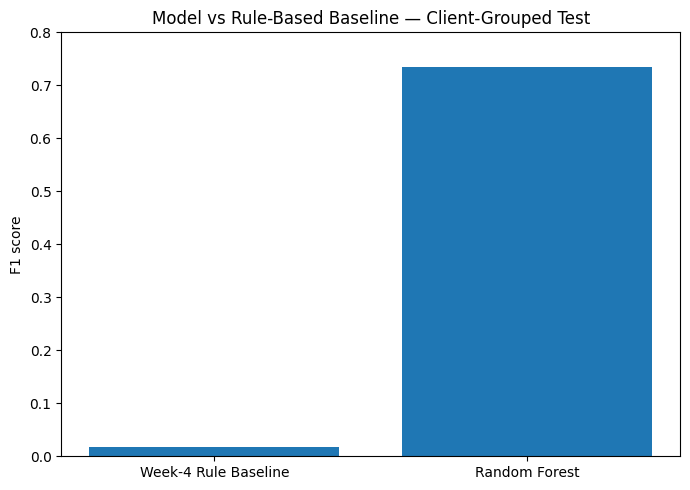

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.bar(
    results["Model"],
    results["F1"]
)

plt.ylabel("F1 score")
plt.title("Model vs Rule-Based Baseline — Client-Grouped Test")
plt.ylim(0, 0.8)

plt.tight_layout()

plt.show()

## 5. Limitations

*What this work cannot claim.*

### Limitations

This analysis does not establish that the model predicts future organic search performance with certainty.

A high model score does not prove that a page will decline, and it does not establish that a content refresh will improve performance. The model is a decision-support signal rather than a causal or calibrated forecast.

The model uses only three historical features: previous-30-day impressions, clicks, and average position. It does not directly model search intent, content quality, technical SEO, seasonality, algorithm changes, business value, or conversions.

The decline label is an analytical definition based on a 20% reduction in impressions; it is not a universal definition of content decline.

The client-grouped validation removes client overlap between training and test data and provides a more conservative evaluation than a row-level random split. However, it does not establish prospective performance on future time periods.

The results should therefore be interpreted as **measured, directional decision-support evidence**, not as proof of causality, guaranteed future performance, or an automated content decision system.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

### Ranked recommendations

The model output is used to prioritize content for human investigation. The ranking is a decision-support queue rather than an automatic content-change system.

| Priority | Content signal / archetype | Recommended action |
|---|---|---|
| 1 | High model-risk, high-visibility content | Investigate first; preserve valuable elements before making changes. |
| 2 | High model-risk, weak-position content | Review search intent, relevance, and on-page coverage. |
| 3 | High model-risk, low-visibility content | Investigate search opportunity and business value before considering a refresh. |
| 4 | Established content with elevated model risk | Review recent performance and content relevance before deciding on intervention. |

### Reason codes

The queue provides human-readable reason codes based on observed signals, including:

- `HIGH_MODEL_RISK`
- `MODERATE_MODEL_RISK`
- `LOW_PRIOR_IMPRESSIONS`
- `NO_PRIOR_CLICKS`
- `WEAKER_PRIOR_POSITION`

These codes explain why an item was prioritized and are intended to support reviewer judgment rather than replace it.

### Recommended workflow

1. Use the model score to prioritize the review queue.
2. Examine the reason codes and content archetype.
3. Review search intent, relevance, business value, historical context, and technical factors.
4. Decide whether to investigate/test, monitor, or take no action.
5. Do not automatically rewrite, delete, redirect, or publish content based solely on the model output.

The ranked queue is therefore best understood as a **human-reviewed content action playbook**.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

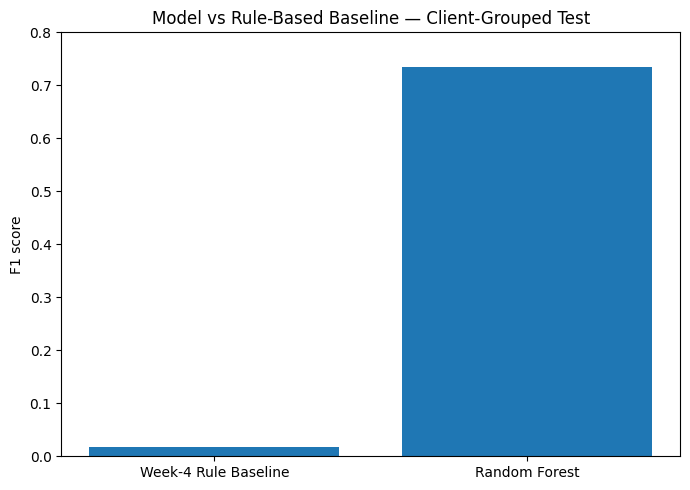

Results table: a:\Working_intern\FlyRank_ML_In\work\outputs\capstone_results.csv
Results figure: a:\Working_intern\FlyRank_ML_In\work\figures\capstone_model_vs_baseline_f1.png


In [18]:
from pathlib import Path
import os

# Find the repository root regardless of the notebook's working directory
cwd = Path.cwd()

repo_root = next(
    p for p in [cwd, *cwd.parents]
    if (p / ".git").exists()
)

figures_dir = repo_root / "work" / "figures"
outputs_dir = repo_root / "work" / "outputs"

figures_dir.mkdir(parents=True, exist_ok=True)
outputs_dir.mkdir(parents=True, exist_ok=True)

# Save results table
results_path = outputs_dir / "capstone_results.csv"
results.to_csv(results_path, index=False)

# Save results figure
plt.figure(figsize=(7, 5))

plt.bar(
    results["Model"],
    results["F1"]
)

plt.ylabel("F1 score")
plt.title("Model vs Rule-Based Baseline — Client-Grouped Test")
plt.ylim(0, 0.8)

plt.tight_layout()

results_figure_path = figures_dir / "capstone_model_vs_baseline_f1.png"

plt.savefig(
    results_figure_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Results table:", results_path)
print("Results figure:", results_figure_path)

### Paper artifacts

The deployed paper uses the following reproducible artifacts generated by the analysis:

- **Model vs baseline F1 chart:** `work/figures/capstone_model_vs_baseline_f1.png`
- **Results table:** generated from the client-grouped evaluation in the notebook.
- **Week-7 ranked action playbook:** `work/figures/w07_decline_score_distribution.png`
- **Week-7 metrics receipt:** `work/outputs/w07_metrics.json`

The underlying bulk dataset and generated queue CSV are not committed to the repository. The notebook contains the analysis steps needed to regenerate the outputs.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

In [19]:
# Error analysis on the client-grouped test set

error_analysis = data.iloc[test_idx][
    ["client_hash_id", "content_hash_id",
     "imp_prev30", "clk_prev30", "pos_prev30",
     "imp_last30", "is_declining"]
].copy()

error_analysis["prediction"] = rf_pred

error_analysis["error_type"] = "Correct"

error_analysis.loc[
    (error_analysis["is_declining"] == 0) &
    (error_analysis["prediction"] == 1),
    "error_type"
] = "False Positive"

error_analysis.loc[
    (error_analysis["is_declining"] == 1) &
    (error_analysis["prediction"] == 0),
    "error_type"
] = "False Negative"

error_summary = (
    error_analysis["error_type"]
    .value_counts()
    .rename_axis("Error type")
    .reset_index(name="Count")
)

display(error_summary)

,Error type,Count
0,Correct,26216
1,False Positive,11133
2,False Negative,5209
